In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
cv=pd.read_csv('chess/cross_validation_dataset.csv')
sub=pd.read_csv('chess/example_submission.csv')
test=pd.read_csv('chess/test_data.csv')
train=pd.read_csv('chess/training_data.csv')

In [4]:
train.head()

,Month #,White Player #,Black Player #,Score
0,1,73,1246,0.5
1,1,73,5097,0.5
2,1,73,5104,0.5
3,1,73,7321,1.0
4,1,73,7375,0.5


In [7]:
train.isnull().describe()

,Month #,White Player #,Black Player #,Score
count,65053,65053,65053,65053
unique,1,1,1,1
top,False,False,False,False
freq,65053,65053,65053,65053


In [8]:
train["Month #"].value_counts()

Month #
93    2540
97    2414
99    2395
95    2236
98    2216
      ... 
29     136
74     119
31     105
32      47
10      46
Name: count, Length: 100, dtype: int64

C:\Users\marku\AppData\Local\Temp\ipykernel_31584\3911095.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['White Player #'])


Text(0.5, 1.0, 'white player')

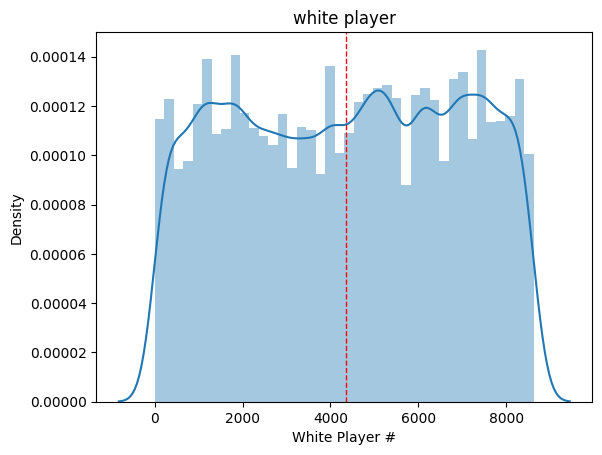

In [15]:
sns.distplot(train['White Player #'])
plt.axvline(train['White Player #'].values.mean(),color='red',linestyle='dashed',linewidth=1)
plt.title('white player')

C:\Users\marku\AppData\Local\Temp\ipykernel_31584\1353728905.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Black Player #'])


Text(0.5, 1.0, 'white player')

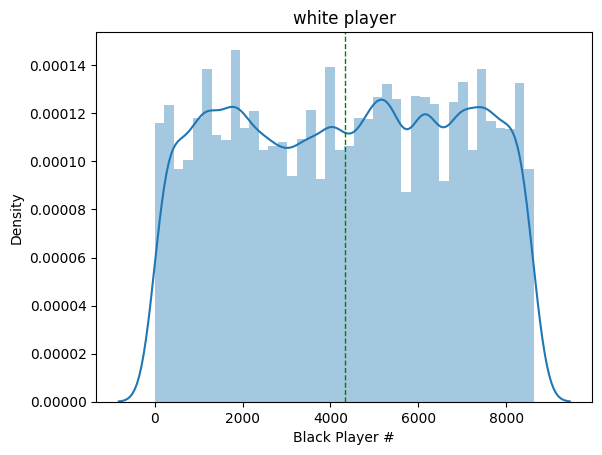

In [18]:
sns.distplot(train['Black Player #'])
plt.axvline(train['Black Player #'].values.mean(),color='green',linestyle='dashed',linewidth=1)
plt.title('white player')

C:\Users\marku\AppData\Local\Temp\ipykernel_31584\2858390738.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Score'],color='g')


Text(0.5, 1.0, 'Score Distribution')

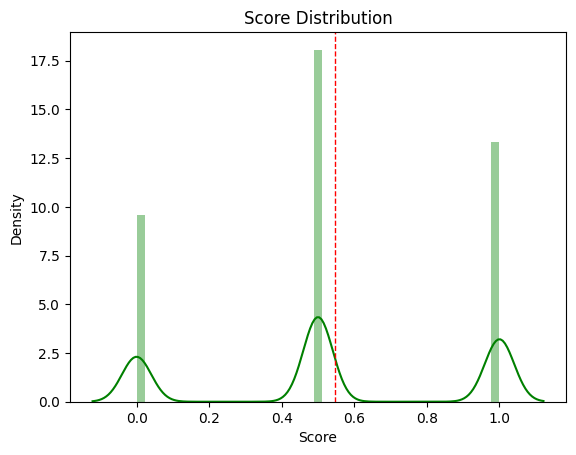

In [21]:
sns.distplot(train['Score'],color='g')
plt.axvline(train['Score'].values.mean(),color='red',linestyle='dashed',linewidth=1)
plt.title('Score Distribution')

In [26]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

trainDf =  pd.read_csv("chess/training_data.csv")
testDf = pd.read_csv("chess/test_data.csv")


In [40]:
x=trainDf.copy().drop(["Score"],axis=1)
y=trainDf.copy()["Score"]

xTest = testDf.copy().drop(["Month #"], axis=1)

lgb_model = lgb.LGBMRegressor(
    categorical_feature= [0],
    task = 'predict',
    application = 'regression',
    objective = 'mae',
    boosting_type="gbdt",
    num_iterations = 2600,
    learning_rate = 0.09,
    num_leaves=9,
    tree_learner='feature',
    max_depth =12,
    min_data_in_leaf=10,
    bagging_fraction = 1,
    bagging_freq = 100,
    reg_sqrt='True',
    metric ='mae',
    feature_fraction = 0.8,
    random_state=42)

In [44]:
lgb_model.fit(x,y)
yTest=lgb_model.predict(xTest)
predictions=pd.DataFrame(testDf["Month #"].copy())
predictions["Score"]=yTest[:]
predictions.Score=predictions.Score.apply(lambda x:round(x))
print(predictions)

C:\Users\marku\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\lightgbm\sklearn.py:821: UserWarning: Found 'application' in params. Will use it instead of 'objective' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'objective' argument")
C:\Users\marku\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(


[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=1, subsample=1.0 will be ignored. Current value: bagging_fraction=1
[LightGBM] [Warning] bagging_freq is set=100, subsample_freq=0 will be ignored. Current value: bagging_freq=100
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=1, subsample=1.0 will be ignored. Current value: bagging_fraction=1
[LightGBM] [Warning] bagging_freq is set=100, subsample_freq=0 will be ignored. Current va

C:\Users\marku\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\lightgbm\sklearn.py:821: UserWarning: Found 'application' in params. Will use it instead of 'objective' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'objective' argument")
